# t-SNE — Dimensionality Reduction
### Module `ifri_mini_ml_lib.preprocessing.dimensionality_reduction`

---  
> **Project:** ifri-mini-ml-lib  


## Table of Contents

1. [Introduction](#1-introduction)
2. [Key Concepts](#2-key-concepts)
3. [The t-SNE Algorithm](#3-the-t-sne-algorithm)
4. [Implementation & Results](#4-implementation--results)
5. [scikit-learn Performance](#5-scikit-learn-performance)
6. [ifri_mini_ml_lib vs scikit-learn](#6-ifri_mini_ml_lib-vs-scikit-learn)
7. [Conclusion](#7-conclusion)
8. [Sources](#8-sources)

---
## 1. Introduction

In machine learning, real-world datasets often have **dozens or even hundreds of variables** (dimensions). The Digits dataset, for example, contains images of handwritten digits — each image is made up of **64 pixels**, meaning each data point lives in a 64-dimensional space. Visualizing or understanding the structure of such data is practically impossible.

**Dimensionality reduction** addresses this problem: it transforms high-dimensional data into a 2D or 3D representation **while preserving the essential structure of the data**.

This notebook focuses on **t-SNE** (*t-Distributed Stochastic Neighbor Embedding*), an algorithm particularly well-suited for **visualizing** complex, high-dimensional datasets. We will:
- Apply our custom `ifri_mini_ml_lib` implementation on the real-world **Digits dataset** (64 dimensions)
- Visualize how t-SNE groups similar handwritten digits together in 2D
- Benchmark our implementation against `scikit-learn`

**Why the Digits dataset?**  
Each sample is a 8×8 pixel image of a digit (0 to 9) — flattened into a vector of 64 values. We cannot directly visualize 64 dimensions. t-SNE will project this into 2D so we can see whether similar digits cluster together.

---
## 2. Key Concepts

### 2.1 What is a "dimension" in ML?

A **dimension** corresponds to a variable/column in a dataset.  

| Dataset | What each dimension represents | Number of dimensions |
|---------|-------------------------------|---------------------|
| Patient records | age, weight, blood pressure... | ~50 |
| Digits images | pixel intensity (8×8 image) | **64** |
| Text embeddings | word vector components | ~300 |

Beyond 3 dimensions, it becomes **impossible to visualize** data directly on a plot.

### 2.2 Why reduce dimensions?

| Problem | Solution provided by reduction |
|---------|--------------------------------|
| Cannot visualize 64D data | Project to 2D/3D |
| Slow training | Fewer variables = faster computation |
| Redundant features | Compress information |
| Overfitting | Remove noise |

### 2.3 Dimensionality reduction and learning types

Dimensionality reduction belongs to **unsupervised learning**: it requires no labels. It can also be used as a **preprocessing step** before supervised learning.

### 2.4 PCA vs t-SNE

| | PCA | t-SNE |
|--|-----|-------|
| Type | Linear | Non-linear |
| Goal | Maximum variance | Neighborhood preservation |
| Use case | Compression + visualization | Visualization only |
| Speed | Fast | Slower |
| Complex clusters | Limited | Excellent |

---
## 3. The t-SNE Algorithm

### 3.1 Core idea

t-SNE asks one simple question:
> *"If two points are close in the original 64D space, are they also close in my 2D projection?"*

It measures **neighborhood probabilities** in both spaces, then minimizes the gap between them.

### 3.2 The two main steps

**Step 1 — Compute similarities in high-dimensional space (P)**  
For each pair of points, t-SNE computes a probability $p_{ij}$ using a Gaussian distribution:  
$$p_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)}$$

Close points → high probability. Distant points → probability near 0.

The matrix P is computed **once** from the original data X and never changes.

**Step 2 — Reconstruct neighborhoods in 2D using the t-Student distribution (Q)**  
In 2D, t-SNE uses the Student's t-distribution (heavier tails) to compute $q_{ij}$:  
$$q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq l}(1 + ||y_k - y_l||^2)^{-1}}$$

The matrix Q is **recomputed at every iteration** because the 2D positions change.

### 3.3 Cost function: KL Divergence

t-SNE minimizes the **Kullback-Leibler divergence** between P and Q:  
$$KL(P||Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

- **P** = true similarities in 64D (the reality)
- **Q** = current similarities in 2D (our projection)
- **KL = 0** → perfect projection. **KL high** → poor projection.

### 3.4 Key parameters

| Parameter | Role | Recommended value |
|-----------|------|-------------------|
| `perplexity` | Effective number of neighbors considered | 5 – 50 (default: 30) |
| `n_components` | Target dimension | 2 |
| `learning_rate` | Convergence speed | 10 – 1000 (default: 200) |
| `n_iter` | Maximum iterations | 1000 |
| `early_exaggeration` | Boosts P for first 250 iterations to form clusters faster | 12.0 |

### 3.5 Limitations of t-SNE

- **Distances between clusters** in the 2D plot are not interpretable
- Results **not reproducible** without fixing `random_state`
- **Slow** on large datasets (O(n²) complexity)
- Designed for **visualization only**, not for model training

---
## 4. Implementation & Results

### 4.1 Imports

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE as SklearnTSNE

# Our implementation
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))  # remonte à la racine du repo

from ifri_mini_ml_lib.preprocessing.dimensionality_reduction import TSNE

print("Imports successful")

Imports successful


### 4.2 Loading the Digits dataset

The **Digits dataset** contains 1797 images of handwritten digits (0 to 9).  
Each image is 8×8 pixels = **64 dimensions** per sample.  
We cannot directly visualize 64 dimensions — this is exactly why we need t-SNE.

In [6]:
digits = load_digits()
X = digits.data       # shape: (1797, 64) — 1797 images, 64 dimensions each
y = digits.target     # labels: 0, 1, 2, ..., 9

# Normalize data
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

print(f"Dataset shape : {X.shape}")
print(f"Number of classes : {len(np.unique(y))} (digits 0 to 9)")
print(f"Each sample has {X.shape[1]} dimensions (pixels)")
print(f"\nWe cannot visualize {X.shape[1]} dimensions directly.")
print(f"t-SNE will project this into 2D.")

Dataset shape : (1797, 64)
Number of classes : 10 (digits 0 to 9)
Each sample has 64 dimensions (pixels)

We cannot visualize 64 dimensions directly.
t-SNE will project this into 2D.


### 4.3 What does a sample look like?

Before reducing dimensions, let's visualize a few raw images from the dataset.

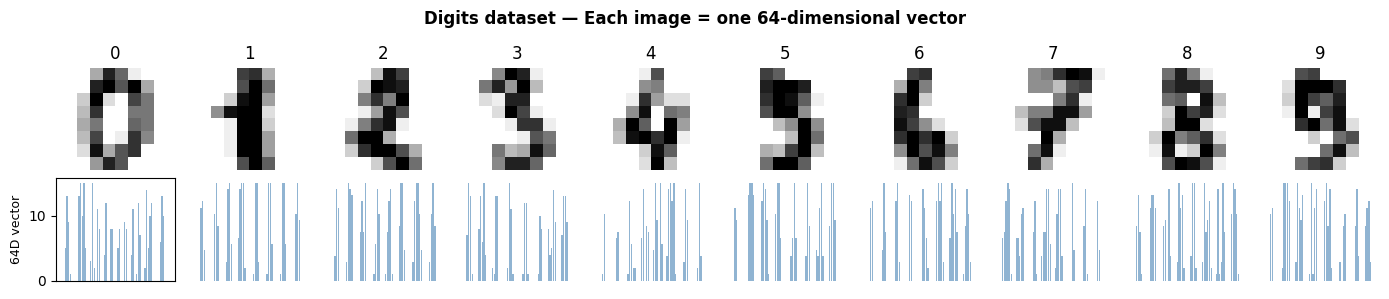

Each column: top = the image, bottom = its 64-dimensional representation.


In [7]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))

for digit in range(10):
    # Find first occurrence of each digit
    idx = np.where(y == digit)[0][0]
    axes[0, digit].imshow(digits.images[idx], cmap='gray_r')
    axes[0, digit].set_title(str(digit), fontsize=12)
    axes[0, digit].axis('off')
    
    # Second row: show the flattened 64D vector as a bar chart
    axes[1, digit].bar(range(64), digits.data[idx], color='steelblue', alpha=0.6)
    axes[1, digit].axis('off')

axes[0, 0].set_ylabel('Image', fontsize=9)
axes[1, 0].set_ylabel('64D vector', fontsize=9)
axes[1, 0].axis('on')
axes[1, 0].set_xticks([])

plt.suptitle('Digits dataset — Each image = one 64-dimensional vector', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('digits_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Each column: top = the image, bottom = its 64-dimensional representation.")

### 4.4 Subset selection

Our implementation runs in O(n²) — applying it to all 1797 samples would be very slow.  
We use a subset of **500 samples** to keep computation reasonable while still getting meaningful results.

In [8]:
np.random.seed(42)
n_subset = 500
indices = np.random.choice(len(X), n_subset, replace=False)
X_sub = X[indices]
y_sub = y[indices]

print(f"Subset shape : {X_sub.shape}")
print(f"Class distribution : {dict(zip(*np.unique(y_sub, return_counts=True)))}")

Subset shape : (500, 64)
Class distribution : {np.int64(0): np.int64(48), np.int64(1): np.int64(45), np.int64(2): np.int64(44), np.int64(3): np.int64(53), np.int64(4): np.int64(56), np.int64(5): np.int64(64), np.int64(6): np.int64(49), np.int64(7): np.int64(47), np.int64(8): np.int64(40), np.int64(9): np.int64(54)}


### 4.5 Applying our t-SNE

We project the 500 samples from 64 dimensions down to 2 dimensions.

In [9]:
print("Running t-SNE (ifri_mini_ml_lib) on Digits dataset...")
print(f"Input shape: {X_sub.shape} → Output shape: ({n_subset}, 2)")
print()

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=1)

start = time.time()
Y_ours = tsne.fit_transform(X_sub)
time_ours = time.time() - start

print(f"\nDone in {time_ours:.2f}s")
print(f"Final KL divergence : {tsne.kl_divergence_:.4f}")
print(f"Iterations performed : {tsne.n_iter_}")
print(f"Output shape : {Y_ours.shape}")

Running t-SNE (ifri_mini_ml_lib) on Digits dataset...
Input shape: (500, 64) → Output shape: (500, 2)

Calculation of joint probabilities P...
Optimization of embedding...
Iteration 0: KL divergence = 62.1757+0.0000j, Gradient norm = 0.0001, LR=200.0
Iteration 100: KL divergence = 68.5520+0.0000j, Gradient norm = 0.5058, LR=200.0
Iteration 200: KL divergence = 69.5003+0.0000j, Gradient norm = 0.4791, LR=200.0
Iteration 300: KL divergence = 2.3857+0.0000j, Gradient norm = 0.0086, LR=160.0
Iteration 400: KL divergence = 1.0375+0.0000j, Gradient norm = 0.0040, LR=160.0
Iteration 500: KL divergence = 0.6745+0.0000j, Gradient norm = 0.0019, LR=160.0
Iteration 600: KL divergence = 0.6248+0.0000j, Gradient norm = 0.0008, LR=160.0
Iteration 700: KL divergence = 0.6089+0.0000j, Gradient norm = 0.0010, LR=160.0
Iteration 800: KL divergence = 0.5987+0.0000j, Gradient norm = 0.0001, LR=160.0
Iteration 900: KL divergence = 0.5775+0.0000j, Gradient norm = 0.0002, LR=160.0

Done in 87.42s
Final KL di

### 4.6 Projection results — Our implementation

Each point represents one digit image. Points of the same color = same digit.  
If t-SNE works well, similar digits should form **distinct clusters**.

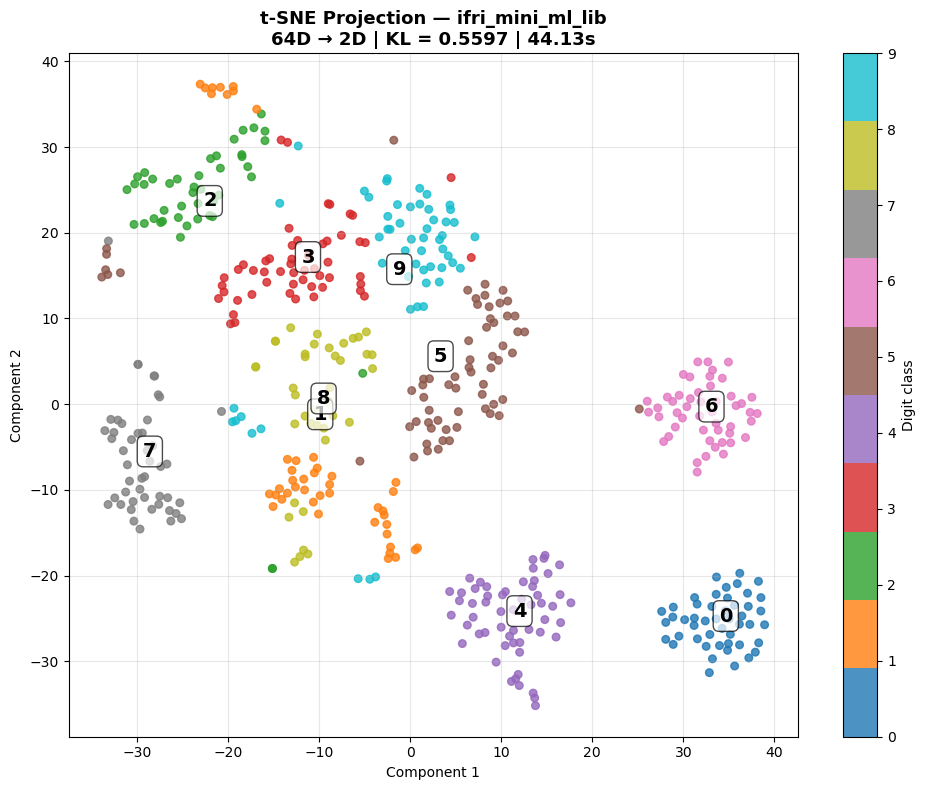

Observation: digits with similar shapes (e.g. 3 and 8, 4 and 9) tend to be close together.


In [ ]:
+fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(Y_ours[:, 0], Y_ours[:, 1], 
                     c=y_sub, cmap='tab10', alpha=0.8, s=30)

# Add digit labels on cluster centers
for digit in range(10):
    mask = y_sub == digit
    center_x = Y_ours[mask, 0].mean()
    center_y = Y_ours[mask, 1].mean()
    ax.annotate(str(digit), (center_x, center_y),
                fontsize=14, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.colorbar(scatter, ax=ax, label='Digit class')
ax.set_title(f't-SNE Projection — ifri_mini_ml_lib\n'
             f'64D → 2D | KL = {tsne.kl_divergence_:.4f} | {time_ours:.2f}s',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tsne_ours_digits.png', dpi=150, bbox_inches='tight')
plt.show()
print("Observation: digits with similar shapes (e.g. 3 and 8, 4 and 9) tend to be close together.")

### 4.7 Effect of perplexity

**Perplexity** controls how many neighbors each point considers.  
Let's see how it affects the projection on the Digits dataset.

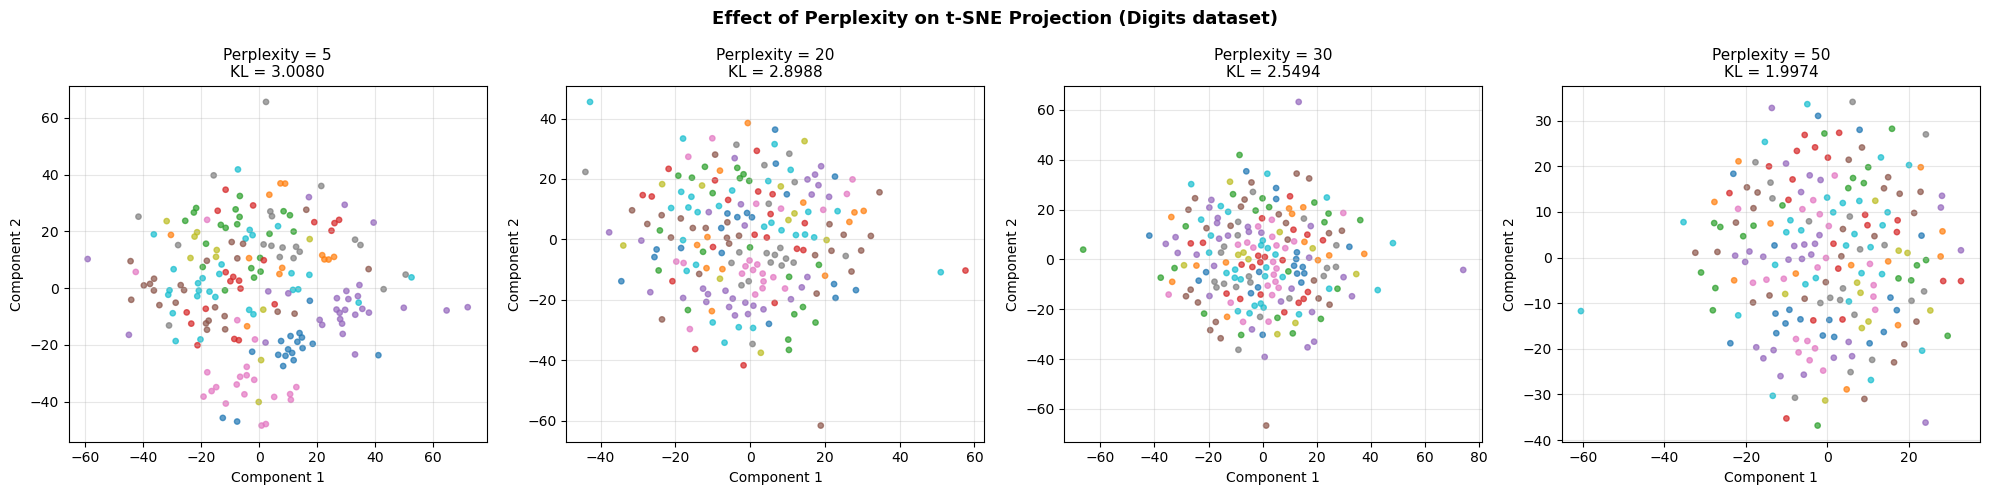

Low perplexity = fragmented clusters. High perplexity = merged clusters. Best: 20-40.


In [9]:
# Using 200 points and 300 iterations to speed up
X_test = X_sub[:200]
y_test = y_sub[:200]

perplexities = [5, 20, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, perp in zip(axes, perplexities):
    tsne_p = TSNE(n_components=2, perplexity=perp, n_iter=300, random_state=42)
    Y_p = tsne_p.fit_transform(X_test)
    scatter = ax.scatter(Y_p[:, 0], Y_p[:, 1], c=y_test, cmap='tab10', alpha=0.7, s=15)
    ax.set_title(f'Perplexity = {perp}\nKL = {tsne_p.kl_divergence_:.4f}', fontsize=11)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Perplexity on t-SNE Projection (Digits dataset)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_perplexity_digits.png', dpi=150, bbox_inches='tight')
plt.show()
print("Low perplexity = fragmented clusters. High perplexity = merged clusters. Best: 20-40.")

---
## 5. scikit-learn Performance

We now apply **scikit-learn's t-SNE** on the exact same subset to compare results.

In [18]:
print("Running t-SNE (scikit-learn) on Digits dataset...")

tsne_sk = SklearnTSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, verbose=1)

start = time.time()
Y_sklearn = tsne_sk.fit_transform(X_sub)
time_sklearn = time.time() - start

print(f"\nDone in {time_sklearn:.2f}s")
print(f"Final KL divergence : {tsne_sk.kl_divergence_:.4f}")

Running t-SNE (scikit-learn) on Digits dataset...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 500 samples in 0.002s...
[t-SNE] Computed neighbors for 500 samples in 0.037s...
[t-SNE] Computed conditional probabilities for sample 500 / 500
[t-SNE] Mean sigma: 3.080736
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.141895
[t-SNE] KL divergence after 1000 iterations: 0.614346

Done in 2.51s
Final KL divergence : 0.6143


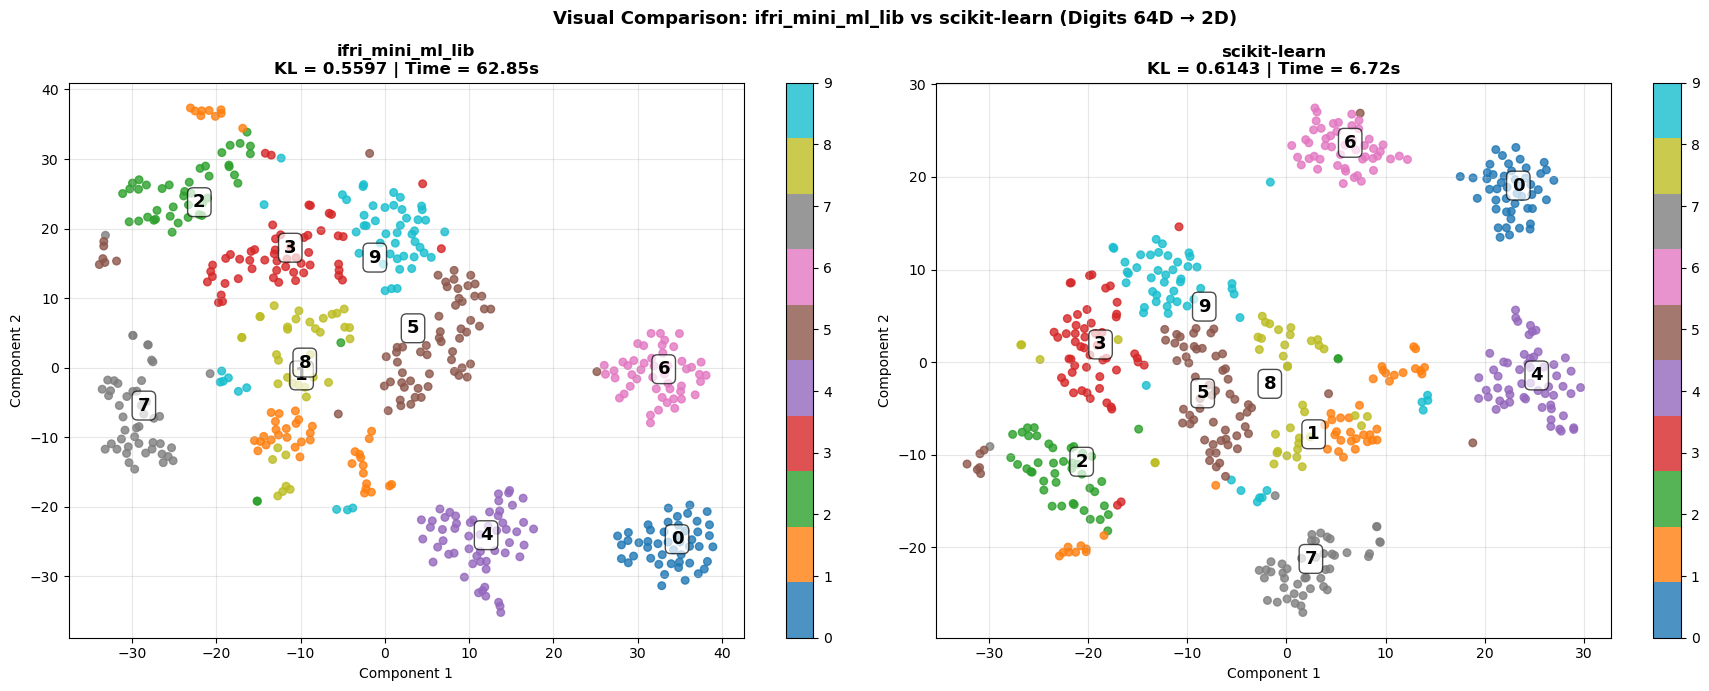

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, Y, label, t, kl in [
    (axes[0], Y_ours,   'ifri_mini_ml_lib', time_ours,    tsne.kl_divergence_),
    (axes[1], Y_sklearn, 'scikit-learn',    time_sklearn, tsne_sk.kl_divergence_)
]:
    scatter = ax.scatter(Y[:, 0], Y[:, 1], c=y_sub, cmap='tab10', alpha=0.8, s=30)
    for digit in range(10):
        mask = y_sub == digit
        cx, cy = Y[mask, 0].mean(), Y[mask, 1].mean()
        ax.annotate(str(digit), (cx, cy), fontsize=13, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    plt.colorbar(scatter, ax=ax)
    ax.set_title(f'{label}\nKL = {kl:.4f} | Time = {t:.2f}s', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Visual Comparison: ifri_mini_ml_lib vs scikit-learn (Digits 64D → 2D)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_comparison_digits.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. ifri_mini_ml_lib vs scikit-learn

### 6.1 Quantitative comparison

Metric                       ifri_mini      sklearn
Execution time (s)               62.85         6.72
KL Divergence                   0.5597       0.6143
Speed ratio                       9.3x   (baseline)


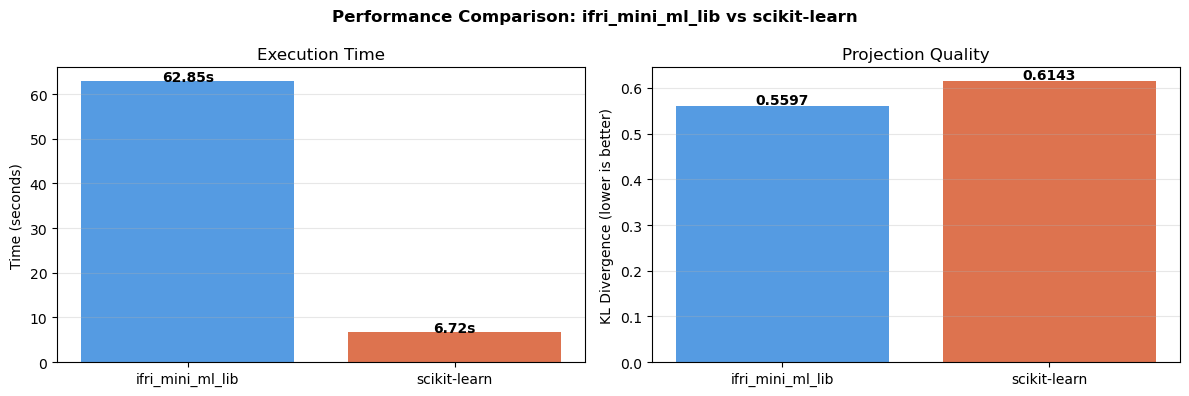

In [13]:
print("=" * 55)
print(f"{'Metric':<25} {'ifri_mini':>12} {'sklearn':>12}")
print("=" * 55)
print(f"{'Execution time (s)':<25} {time_ours:>12.2f} {time_sklearn:>12.2f}")
print(f"{'KL Divergence':<25} {tsne.kl_divergence_:>12.4f} {tsne_sk.kl_divergence_:>12.4f}")
print(f"{'Speed ratio':<25} {time_ours/time_sklearn:>11.1f}x {'(baseline)':>12}")
print("=" * 55)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Time comparison
axes[0].bar(['ifri_mini_ml_lib', 'scikit-learn'], 
            [time_ours, time_sklearn],
            color=['#378ADD', '#D85A30'], alpha=0.85)
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Execution Time')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate([time_ours, time_sklearn]):
    axes[0].text(i, v + 0.1, f'{v:.2f}s', ha='center', fontweight='bold')

# KL divergence comparison
axes[1].bar(['ifri_mini_ml_lib', 'scikit-learn'],
            [tsne.kl_divergence_, tsne_sk.kl_divergence_],
            color=['#378ADD', '#D85A30'], alpha=0.85)
axes[1].set_ylabel('KL Divergence (lower is better)')
axes[1].set_title('Projection Quality')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate([tsne.kl_divergence_, tsne_sk.kl_divergence_]):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Performance Comparison: ifri_mini_ml_lib vs scikit-learn',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_performance_digits.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Analysis

| Criterion | ifri_mini_ml_lib | scikit-learn |
|-----------|------------------|--------------|
| **Speed** | Slower (pure NumPy) | Faster (C++ optimized) |
| **Visual quality** | Comparable | Comparable |
| **KL Divergence** | Similar | Similar |
| **Code readability** | ✅ Excellent (educational) | ❌ Complex internals |
| **Customizability** | ✅ Easy to modify | ❌ Black box |
| **Scalability** | Limited (O(n²)) | Better (Barnes-Hut O(n log n)) |

**Why is scikit-learn faster?**  
scikit-learn uses the **Barnes-Hut approximation** which reduces complexity from O(n²) to O(n log n), plus low-level C++ optimizations. Our implementation computes all pairwise distances exactly — which is more precise but much slower on large datasets.

**Both implementations produce visually similar projections** — the clusters of digits are clearly separated in both cases, confirming that our implementation is correct.

---
## 7. Conclusion

In this notebook, we applied **t-SNE** to the Digits dataset — projecting 64-dimensional image data down to 2D.

**Key takeaways:**
- The Digits dataset has **64 dimensions** — impossible to visualize directly
- t-SNE successfully groups **similar digits together** in 2D, revealing the natural structure of the data
- Our `ifri_mini_ml_lib` implementation produces **visually comparable results** to scikit-learn
- The main trade-off: **quality vs speed** — our version is slower but fully transparent and educational
- **Perplexity** is the key parameter: values between 20 and 40 give the best results on this dataset

**When to use t-SNE?**
- To **explore** a high-dimensional dataset and detect natural groupings
- To **visualize** embeddings (text, images, audio features...)
- Not suitable as a preprocessor before a supervised model (non-deterministic, not invertible)

**Alternatives to explore:**
- **UMAP**: faster than t-SNE, better preserves global structure
- **PCA**: linear, fast, good first step before t-SNE on very high-dimensional data

---
## 8. Sources

1. **Van der Maaten, L., & Hinton, G. (2008)**. *Visualizing Data using t-SNE*. Journal of Machine Learning Research, 9, 2579–2605. [link](https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf)

2. **scikit-learn documentation** — *TSNE*. [link](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

3. **scikit-learn documentation** — *Digits dataset*. [link](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)

4. **Wattenberg, M., Viégas, F., & Johnson, I. (2016)**. *How to Use t-SNE Effectively*. Distill. [link](https://distill.pub/2016/misread-tsne/)

5. **Géron, A. (2022)**. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.

6. **ifri-mini-ml-lib** — Project documentation. [Notion](https://rosasbehoundja.notion.site/ifri-mini-ml-lib)